In [1]:
from PIL import Image
import numpy as np

# Load image
img = Image.open("image1.jpg").convert("RGBA")  # RGBA ensures 4 channels
pixels = np.array(img)  # shape: (height, width, 4)

# Flatten to list of color vectors
colors = pixels.reshape(-1, 4)  # shape: (num_pixels, 4)

print("First 10 RGBA color vectors:")
print(colors[:10])

First 10 RGBA color vectors:
[[  1 111 162 255]
 [  0 111 161 255]
 [  0 112 162 255]
 [  0 112 162 255]
 [  0 109 160 255]
 [  1 108 160 255]
 [  1 108 160 255]
 [  0 108 159 255]
 [  0 109 160 255]
 [  1 108 160 255]]


In [2]:
# Example 4x4 RGBA transformation matrix
# This swaps R and B, slightly boosts G, leaves alpha unchanged
M = np.array([
    [0, 0, 1, 0],  # R' = B
    [0, 1.2, 0, 0],# G' = 1.2*G
    [1, 0, 0, 0],  # B' = R
    [0, 0, 0, 1]   # A' = A
])

# Apply matrix to all pixels
transformed_colors = colors @ M.T  # shape: (num_pixels, 4)
transformed_colors = np.clip(transformed_colors, 0, 255).astype(np.uint8)

In [5]:
# Reshape back to original image shape
new_pixels = transformed_colors.reshape(pixels.shape)

# Convert to Image
new_img = Image.fromarray(new_pixels, mode="RGBA")
new_img.show()           # show in default image viewer
new_img.save("output.png")  # save to file

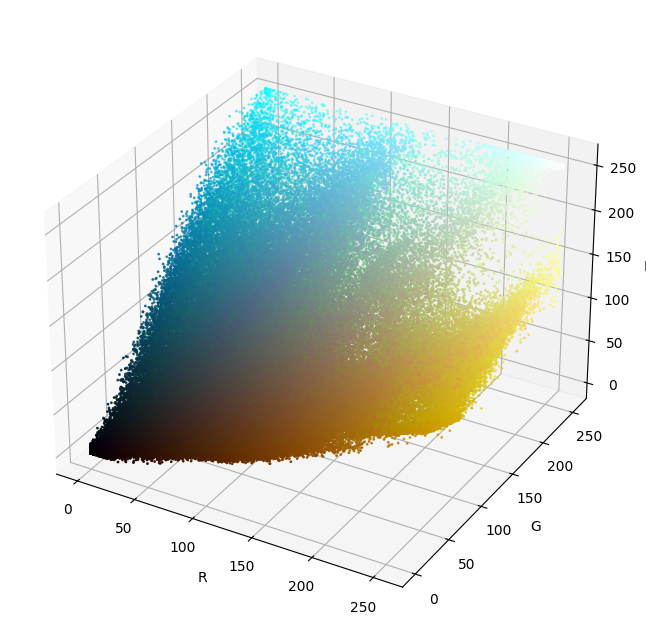

In [4]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Use RGB only for 3D plot
rgb = transformed_colors[:, :3]

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(rgb[:,0], rgb[:,1], rgb[:,2], c=rgb/255.0, s=1)
ax.set_xlabel("R")
ax.set_ylabel("G")
ax.set_zlabel("B")
plt.show()